# Explore chemical space generated by each representation

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from deepmol.loaders import CSVLoader
from sklearn.manifold import TSNE
import pandas as pd

labels_ = {
        'C00341': 'Geranyl diphosphate',
        'C01789': 'Campesterol',
        'C00078': 'Tryptophan',
        'C00049': 'L-Aspartate',
        'C00183': 'L-Valine',
        'C03506': 'Indoleglycerol phosphate',
        'C00187': 'Cholesterol',
        'C00079': 'L-Phenylalanine',
        'C00047': 'L-Lysine',
        'C01852': 'Secologanin',
        'C00407': 'L-Isoleucine',
        'C00129': 'Isopentenyl diphosphate',
        'C00235': 'Dimethylallyl diphosphate',
        'C00062': 'L-Arginine',
        'C00353': 'Geranylgeranyl diphosphate',
        'C00148': 'L-Proline',
        'C00073': 'L-Methionine',
        'C00108': 'Anthranilate',
        'C00123': 'L-Leucine',
        'C00135': 'L-Histidine',
        'C00448': 'Farnesyl diphosphate',
        'C00082': 'L-Tyrosine',
        'C00041': 'L-Alanine',
        'C00540': 'Cinnamoyl-CoA',
        'C01477': 'Apigenin',
        'C05903': 'Kaempferol',
        'C05904': 'Pelargonin',
        'C05905': 'Cyanidin',
        'C05908': 'Delphinidin',
        'C00389': 'Quercetin',
        'C01514': 'Luteolin',
        'C09762': "Liquiritigenin",
        'C00509': 'Naringenin',
        'C00223': 'p-Coumaroyl-CoA'
    }

def generate_tsne_with_featurizer(featurizer, name=None, method=TSNE):
    if not name:
        name = featurizer.__class__.__name__

    # Load and featurize data
    dataset = CSVLoader(dataset_path="../final_dataset_top_v2.csv",
                      smiles_field="smiles").create_dataset()
    dataset = featurizer.transform(dataset)
    X = dataset.X

    # Perform t-SNE
    if method.__name__ == "TSNE":
        perplexity = min(30, X.shape[0] / 10)

        tsne = method(n_components=2, random_state=42, perplexity=perplexity)
    else:
        tsne = method(n_components=2, random_state=42)

    X_embedded = tsne.fit_transform(X)

    # Load labels
    pandas_dataset = pd.read_csv("../final_dataset_top_v2.csv")
    label_columns = pandas_dataset.columns[2:]
    label_counts = pandas_dataset[label_columns].sum().sort_values(ascending=False)
    
    # most_frequent_labels = label_counts.index.tolist()
    
    # Assign classes
    def get_assigned_classes(row):
        total = 1
        # check if it has more than one ones
        for col in label_columns:
            if row[col] == 1:
                if row[label_columns].sum() > 1 and total == 1:
                    total += 1
                    continue
                else:
                    return col

        return "other"

    pandas_dataset['Assigned_Class'] = pandas_dataset.apply(get_assigned_classes, axis=1)

    # Define colors and markers
    opacity = 0.8
    colors = {
        'blue': (55/255, 126/255, 184/255, opacity),
        'orange': (255/255, 127/255, 0/255, opacity),
        'green': (77/255, 175/255, 74/255, opacity),
        'pink': (247/255, 129/255, 191/255, opacity),
        'brown': (166/255, 86/255, 40/255, opacity),
        'purple': (152/255, 78/255, 163/255, opacity),
        'lime': (50/255, 205/255, 50/255, opacity),  # Replaced gray with lime
        'red': (228/255, 26/255, 28/255, opacity),
        'yellow': (222/255, 222/255, 0/255, opacity),
        'cyan': (0/255, 183/255, 235/255, opacity),
        'dark_blue': (0/255, 0/255, 139/255, opacity),
    }

    # Marker styles
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'd']

    # Prepare color mapping
    color_values = list(colors.values())
    unique_classes = pandas_dataset["Assigned_Class"].unique().tolist()
    if "other" in unique_classes:
        unique_classes.remove("other")
        unique_classes.insert(0, "other")  # Put "Other" first

    # Create t-SNE plot
    plt.figure(figsize=(10, 8))
    legend_handles = []


    for i, cls in enumerate(unique_classes):
        mask = pandas_dataset['Assigned_Class'] == cls
        color = color_values[i % len(color_values)]
        marker = markers[i % len(markers)]
        if cls in labels_:
            cls = labels_[cls]

        # Plot with both color and marker
        plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1],
                   color=color,
                   label=cls,
                   s=30,
                   marker=marker,
                   alpha=opacity)

        # Create legend handle with both color and marker
        legend_handles.append(plt.Line2D([0], [0],
                                       marker=marker,
                                       color='w',
                                       label=cls,
                                       markerfacecolor=color,
                                       markersize=7))

    plt.title(f'{method.__name__} plot of {name}', size=17)
    plt.grid(True)
    plt.xlabel(f'{method.__name__} 1')
    plt.ylabel(f'{method.__name__} 2')
    plt.tight_layout()
    plt.savefig(f"{method.__name__}_plot_{name}.png", bbox_inches='tight', dpi=300, transparent=True)

    # Create separate legend figure
    fig_legend = plt.figure(figsize=(10, 0.5))
    fig_legend.legend(handles=legend_handles,
                     loc='center',
                     ncol=1,
                     title="Pathway")
    fig_legend.savefig(f"{method.__name__}_legend_{name}.png", bbox_inches='tight', dpi=300, transparent=True)
    plt.close(fig_legend)


2025-10-23 14:22:14.343348: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-23 14:22:14.343387: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-23 14:22:14.344734: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-23 14:22:14.352368: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-10-23 14:22:15.324730: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
/home/jcapela/.local/share/mamba/envs/np_benchmark/lib/python3.10/site-packages/deepmol/compound_featurization/__init__.py:20: UserWarning: Mol2Vec not available. Please install it to use it. (pip install git+https://github.com/samoturk/mol2vec#egg=mol2vec)
  warnings.warn("Mol2Vec not available. Please install it to use it. "
/home/jcapela/.local/share/mamba/envs/np_benchmark/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator VarianceThreshold from version 1.2.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jcapela/.local/share/mamba/envs/np_benchmar

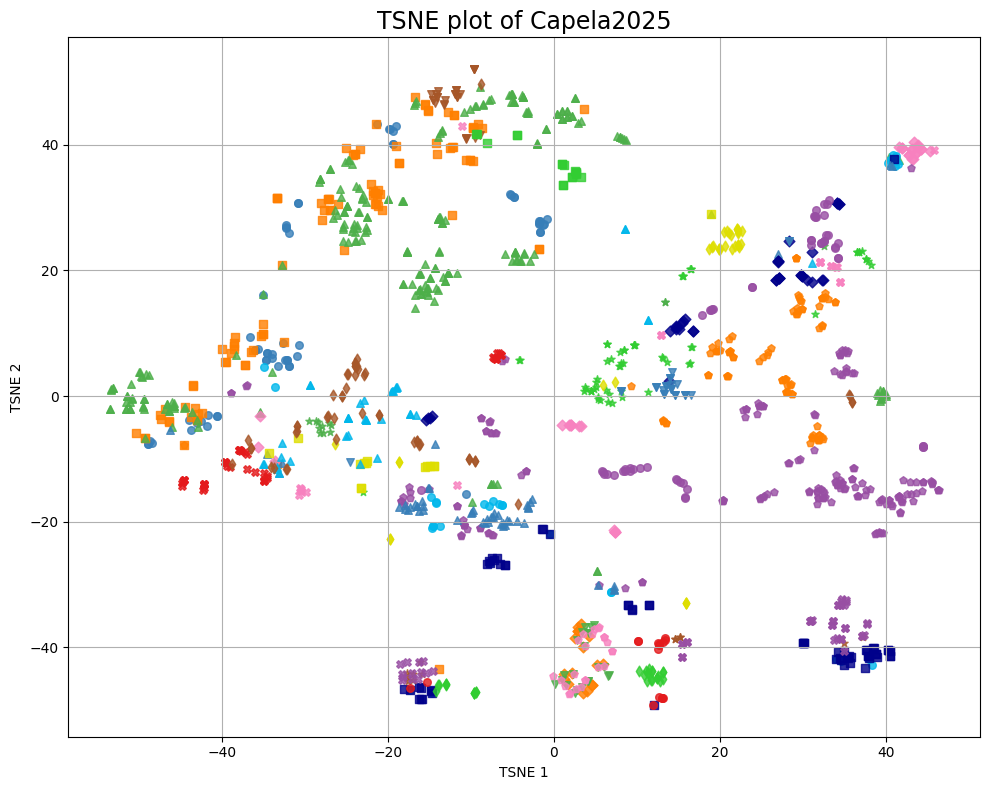

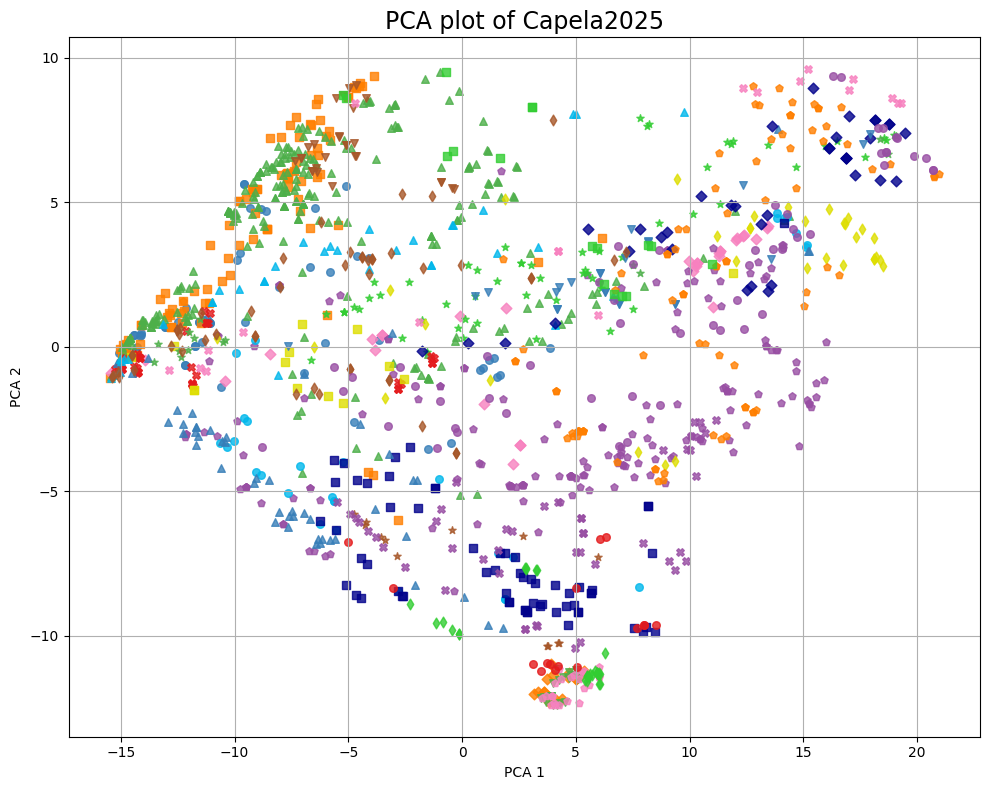

In [4]:
from deepmol.pipeline import Pipeline
from sklearn.decomposition import PCA

pipeline = Pipeline.load("../ridge_classifier_layered_fingerprints_variance_selector/")
generate_tsne_with_featurizer(pipeline, name="Capela2025")
generate_tsne_with_featurizer(pipeline, method=PCA, name="Capela2025")

NPClassifierFP: 100%|██████████| 1428/1428 [00:01<00:00, 714.84it/s]


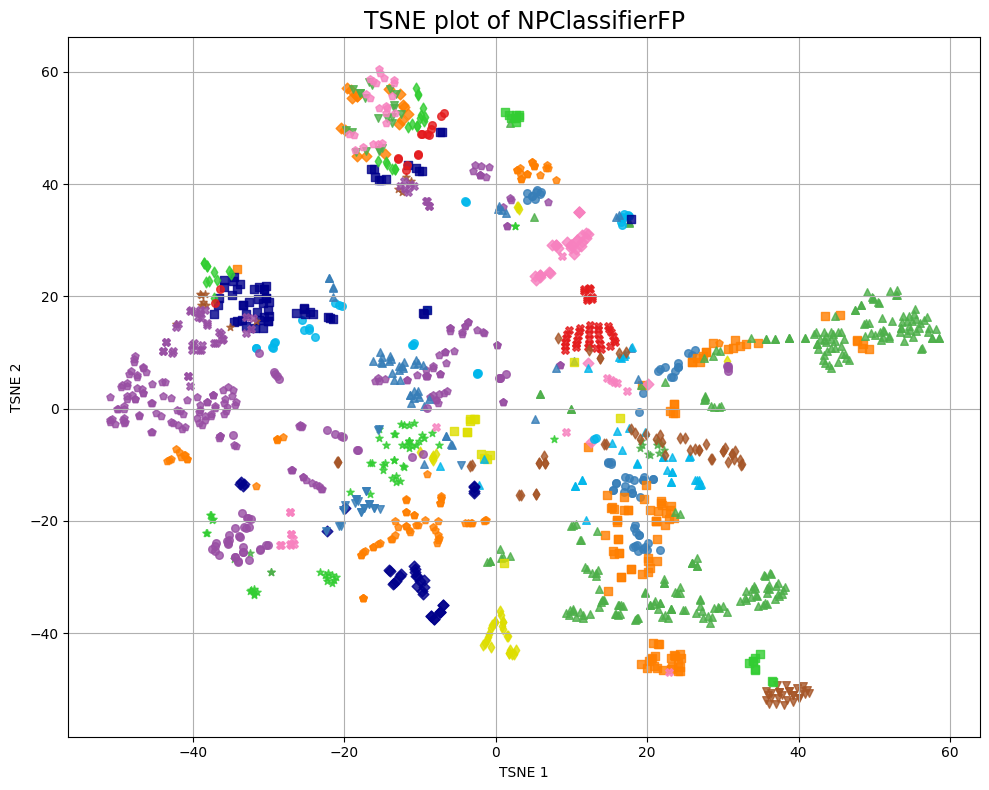

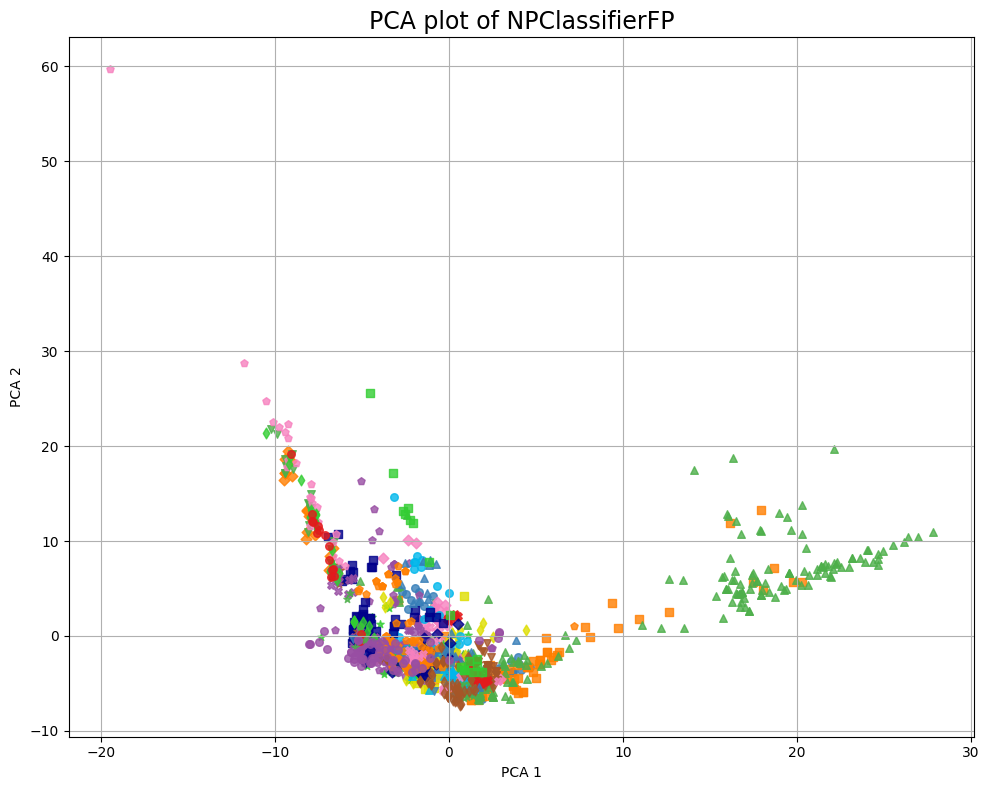

In [5]:
from deepmol.compound_featurization import NPClassifierFP
from sklearn.decomposition import PCA

featurizer = NPClassifierFP()
generate_tsne_with_featurizer(featurizer)
generate_tsne_with_featurizer(featurizer, method=PCA)

NeuralNPFP:   0%|          | 0/1428 [00:00<?, ?it/s]/home/jcapela/.local/share/mamba/envs/np_benchmark/lib/python3.10/site-packages/deepmol/compound_featurization/neural_npfp_generator.py:82: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  fp = torch.tensor([fp], dtype=torch.float)
NeuralNPFP: 100%|██████████| 1428/1428 [00:04<00:00, 297.17it/s]


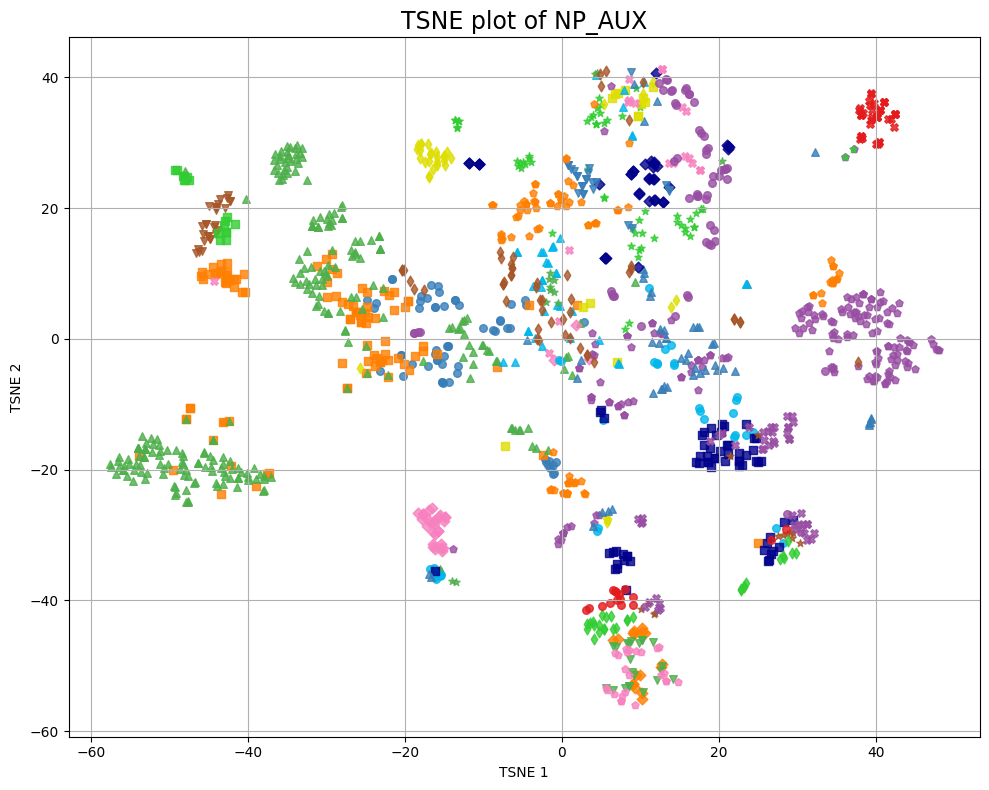

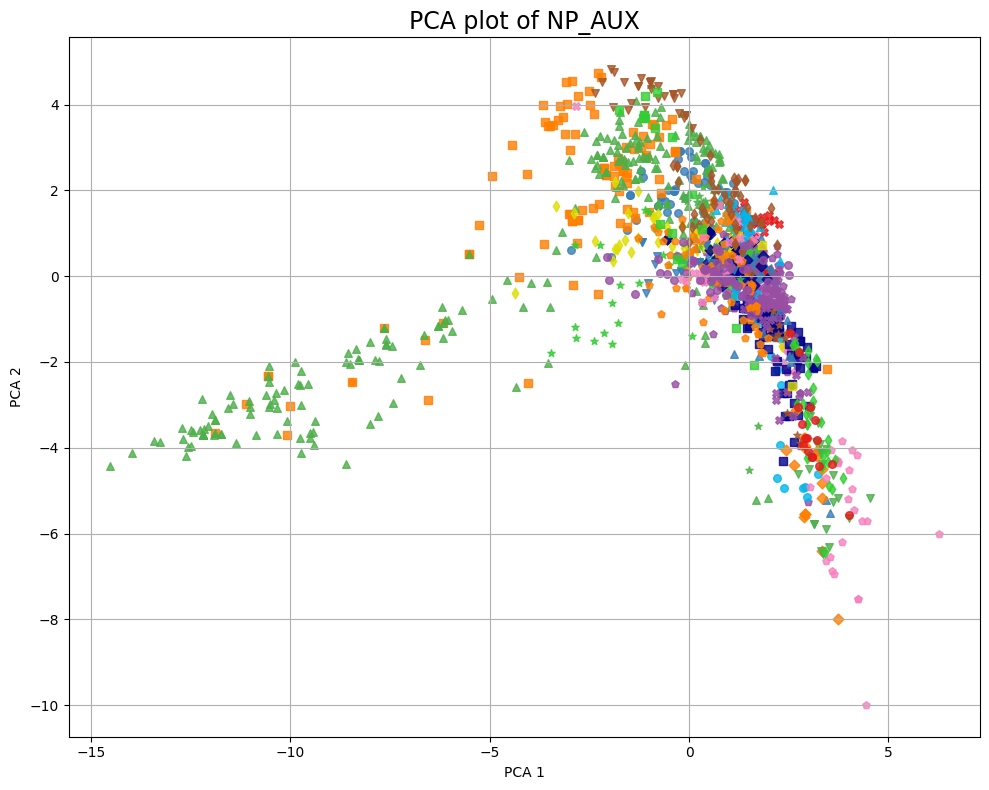

In [6]:
from deepmol.compound_featurization import NeuralNPFP

featurizer = NeuralNPFP()
generate_tsne_with_featurizer(featurizer, name="NP_AUX")
generate_tsne_with_featurizer(featurizer, name="NP_AUX", method=PCA)

BiosynfoniKeys:   0%|          | 0/1428 [00:00<?, ?it/s]

BiosynfoniKeys: 100%|██████████| 1428/1428 [00:01<00:00, 808.30it/s]


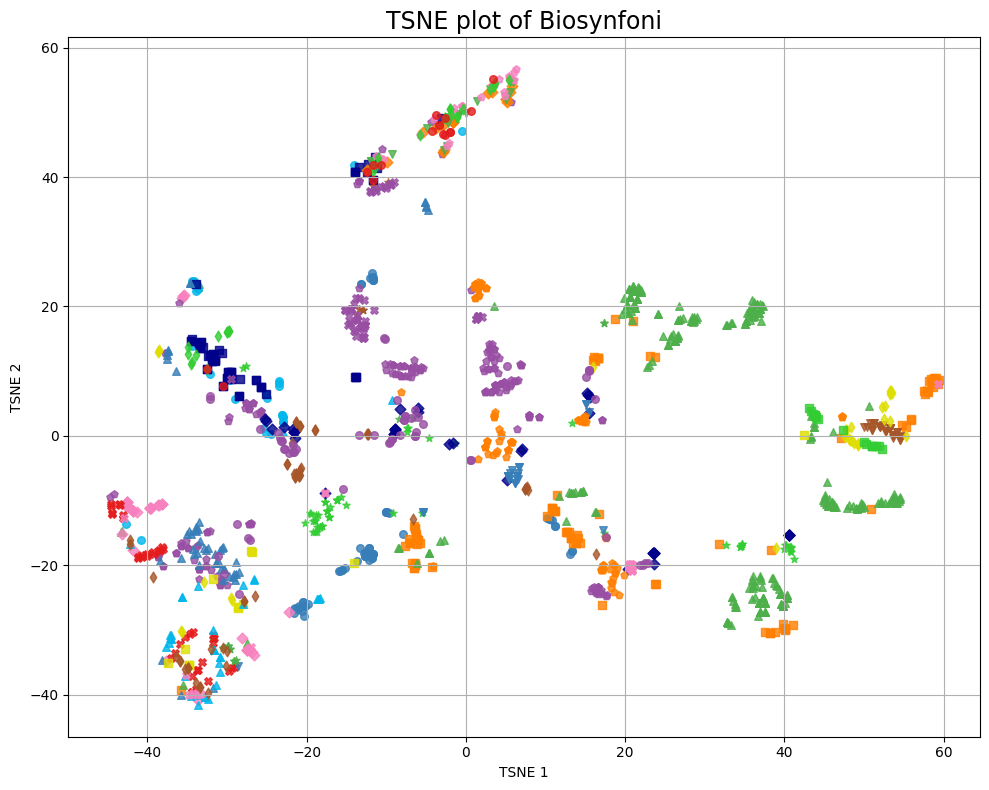

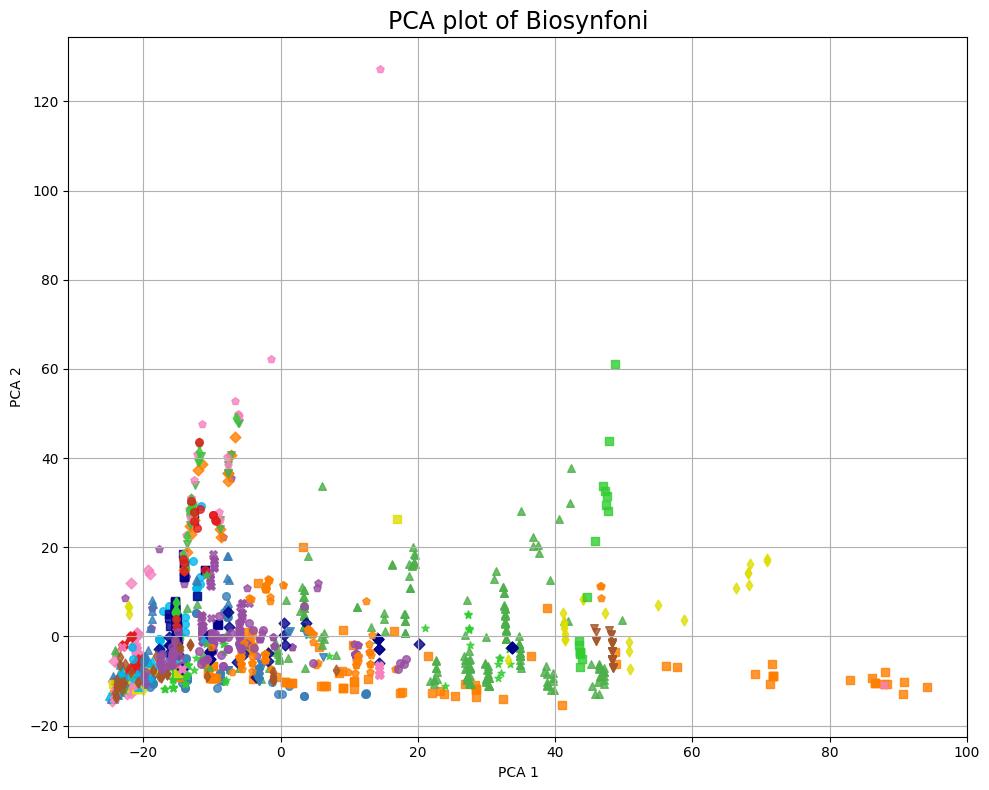

In [7]:
from deepmol.compound_featurization import BiosynfoniKeys

featurizer = BiosynfoniKeys()
generate_tsne_with_featurizer(featurizer, name="Biosynfoni")
generate_tsne_with_featurizer(featurizer, name="Biosynfoni", method=PCA)

Some weights of BertModel were not initialized from the model checkpoint at ../../NPBERT/model.pt and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


100%|██████████| 1428/1428 [00:09<00:00, 152.29it/s]


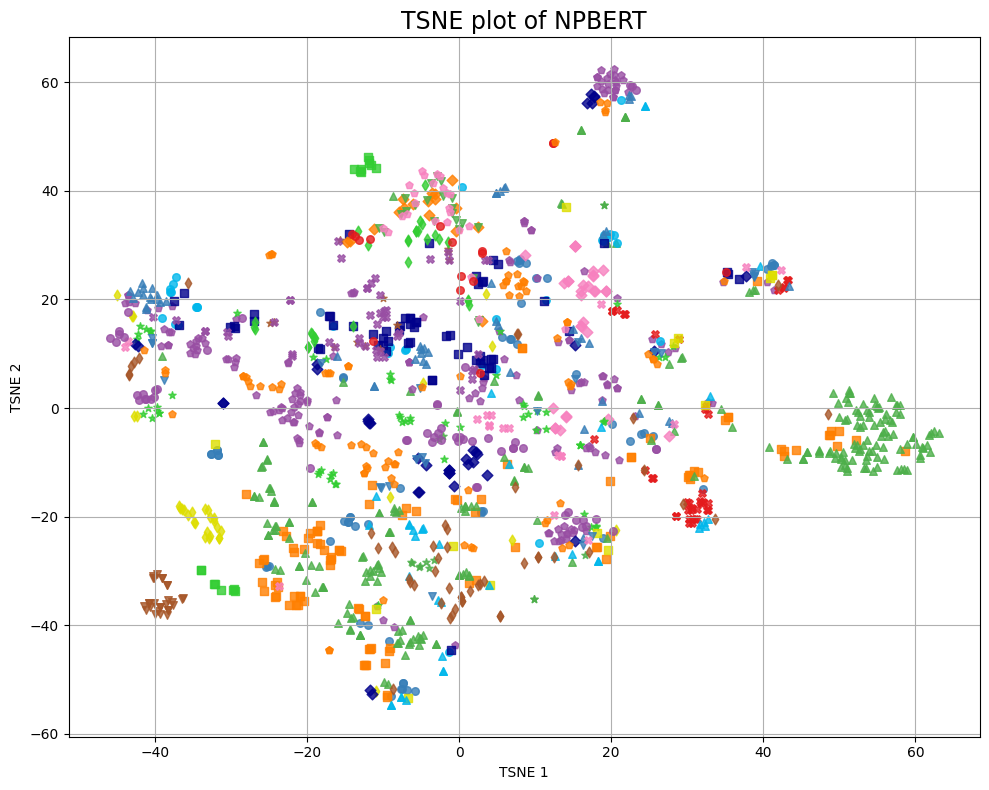

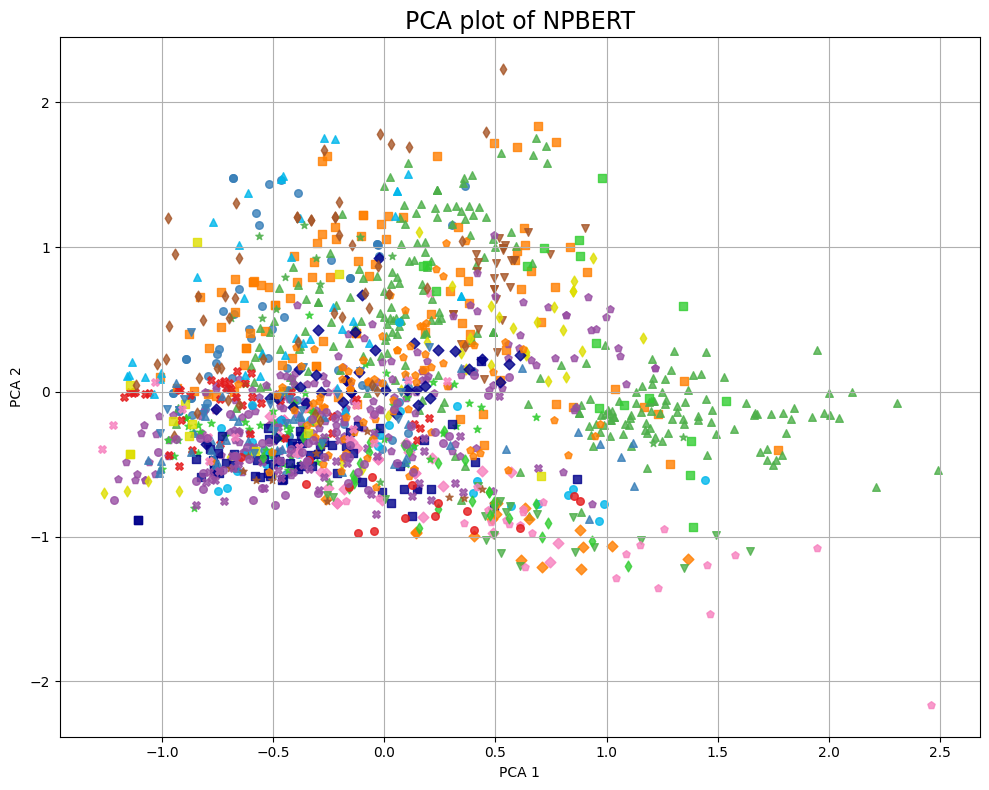

In [8]:
import os
from deepmol.compound_featurization import LLM
from transformers import BertConfig, BertModel

from deepmol.standardizer import ChEMBLStandardizer

from deepmol.tokenizers import NPBERTTokenizer

transformer = LLM(model_path="../../NPBERT", model=BertModel, config_class=BertConfig,
                          tokenizer=NPBERTTokenizer(vocab_file=os.path.join("../../NPBERT", "vocab.txt")), device="cuda:0")

generate_tsne_with_featurizer(transformer, name="NPBERT")
generate_tsne_with_featurizer(transformer, name="NPBERT", method=PCA)

100%|██████████| 1428/1428 [00:48<00:00, 29.14it/s]


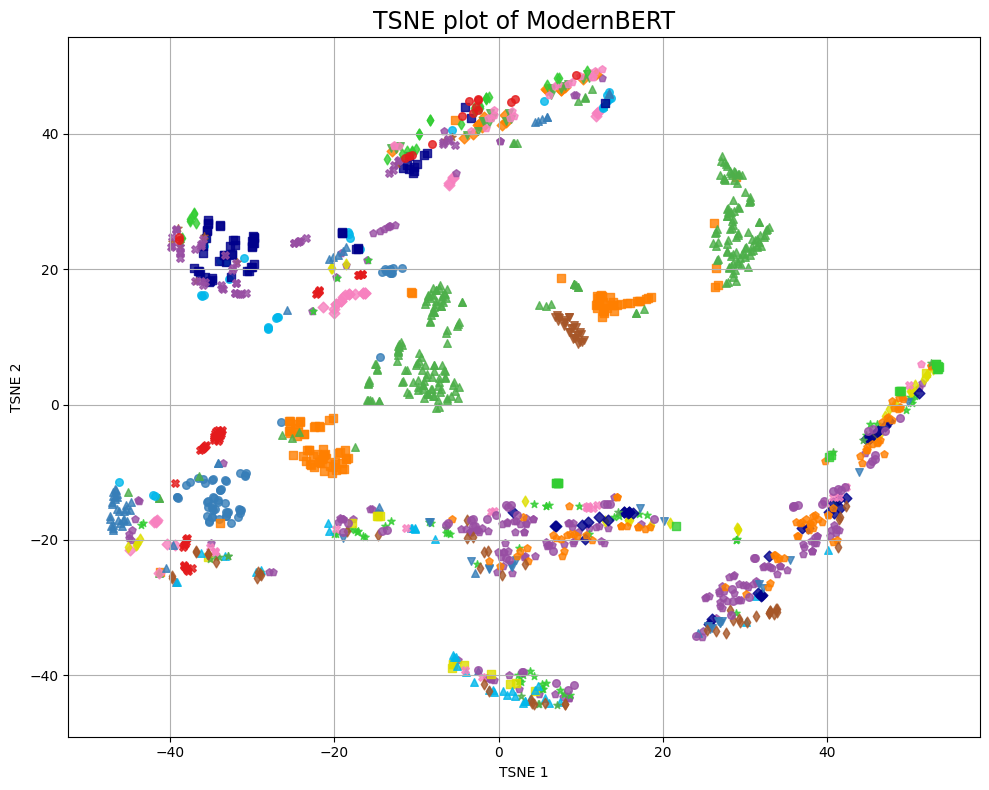

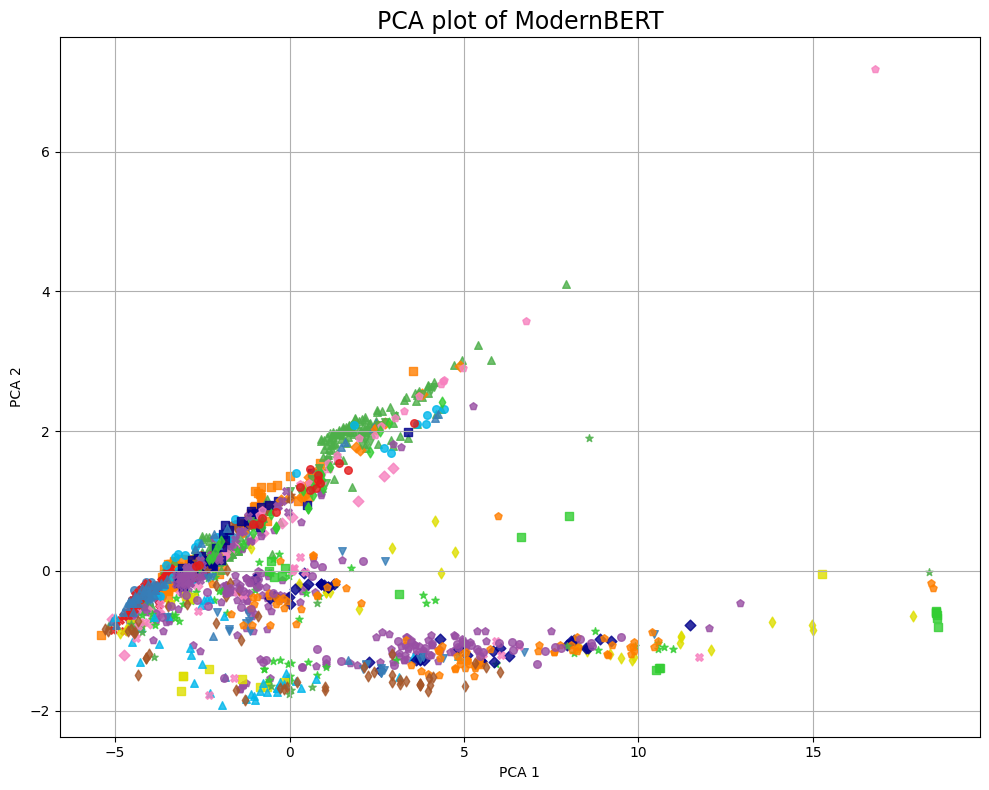

In [9]:
import os
from deepmol.compound_featurization import LLM

from deepmol.compound_featurization import LLM
from transformers import ModernBertModel, ModernBertConfig

transformer = LLM(model_path="../../ModernBERT", model=ModernBertModel, config_class=ModernBertConfig, device="cuda:1")

generate_tsne_with_featurizer(transformer, name="ModernBERT")
generate_tsne_with_featurizer(transformer, name="ModernBERT", method=PCA)

MorganFingerprint:  34%|███▍      | 488/1428 [00:00<00:01, 908.80it/s]

MorganFingerprint: 100%|██████████| 1428/1428 [00:01<00:00, 822.74it/s]


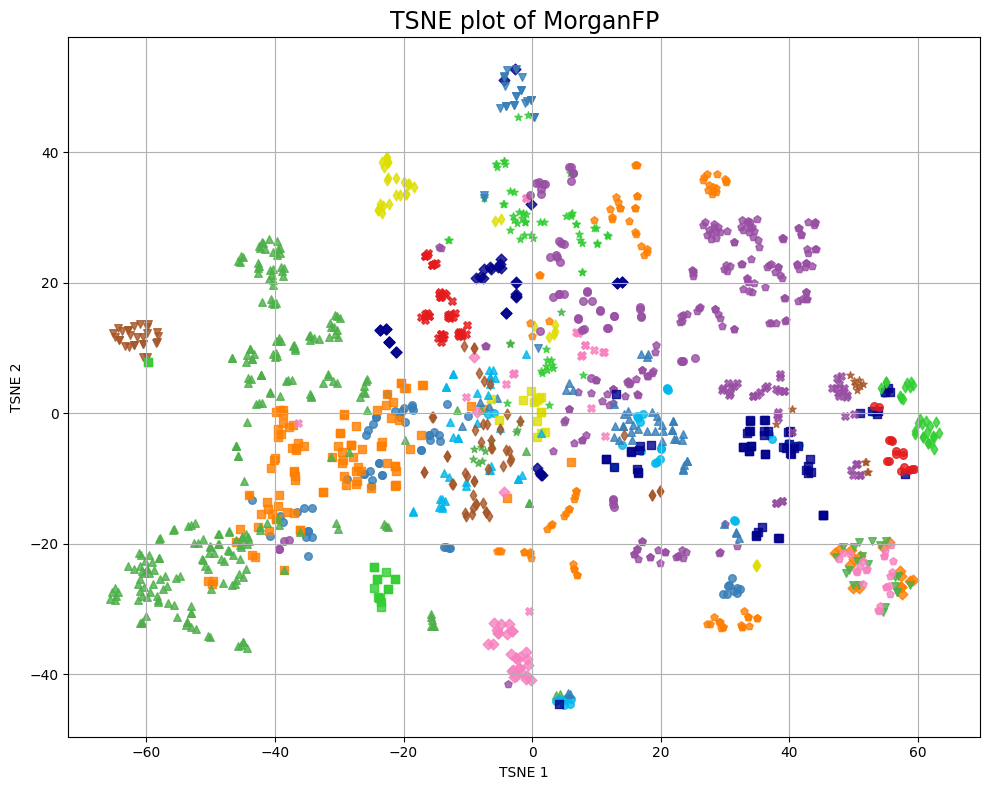

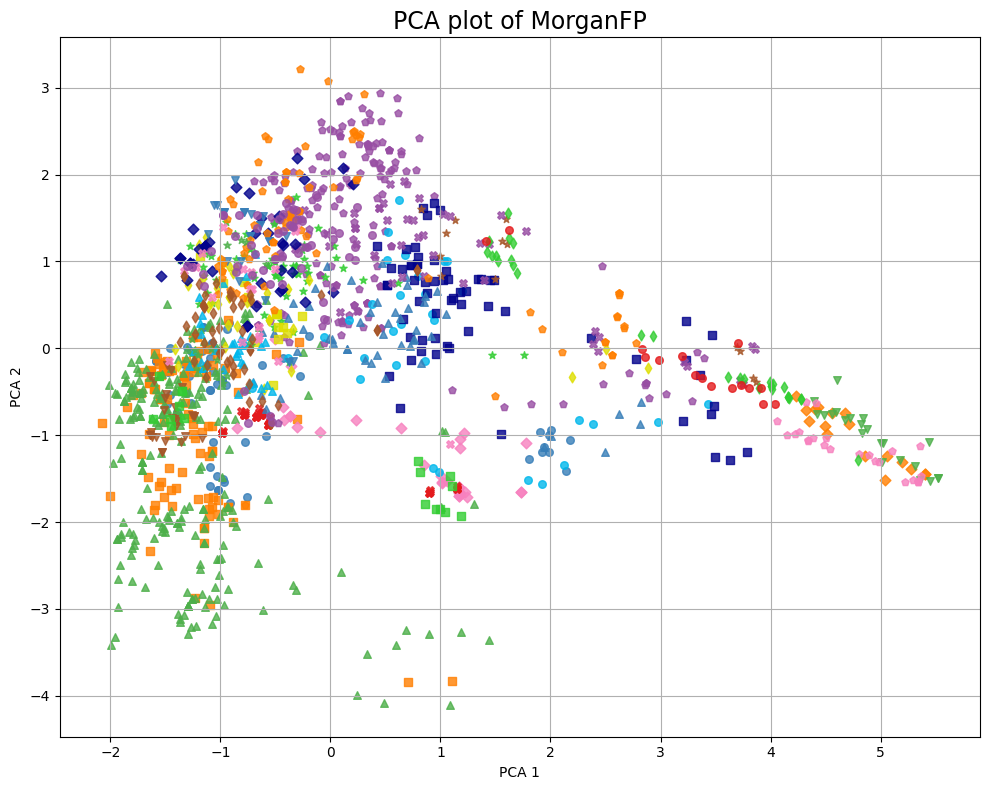

In [10]:
from deepmol.compound_featurization import MorganFingerprint

featurizer = MorganFingerprint()
generate_tsne_with_featurizer(featurizer, name="MorganFP")
generate_tsne_with_featurizer(featurizer, name="MorganFP", method=PCA)

MHFP:   2%|▏         | 27/1428 [00:00<00:22, 62.30it/s]

MHFP: 100%|██████████| 1428/1428 [00:15<00:00, 92.17it/s] 


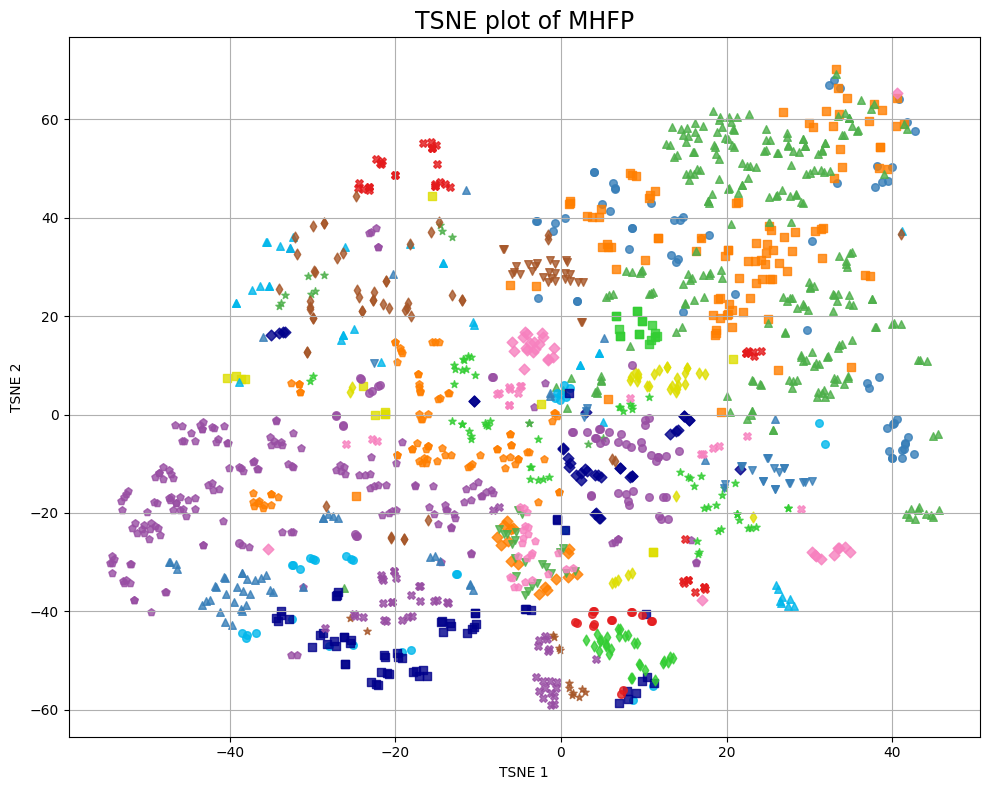

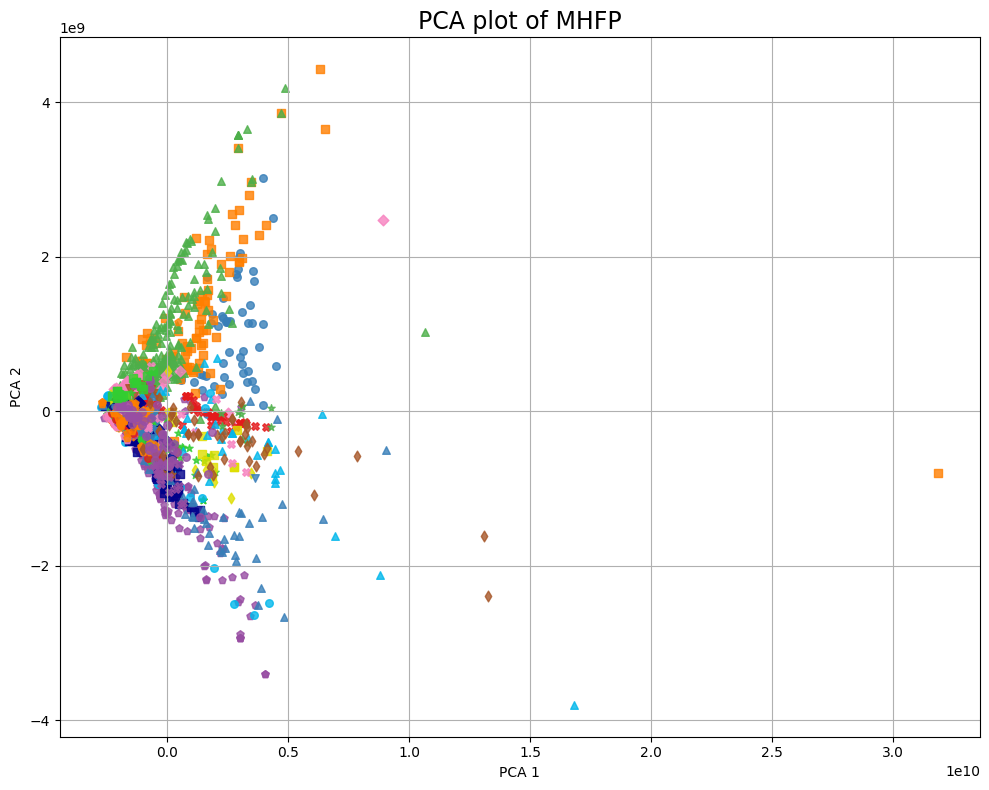

In [11]:
from deepmol.compound_featurization import MHFP

featurizer = MHFP()
generate_tsne_with_featurizer(featurizer, name="MHFP")
generate_tsne_with_featurizer(featurizer, name="MHFP", method=PCA)
